# Task 5: Final LR Elastic Net Training and SHAP

This notebook completes Task 5 after winner selection from tuned full-feature rnCV and feature-selection analysis.

- Winner algorithm from model analysis: `lr_elasticnet`
- Final deployment choice: full-feature LR Elastic Net pipeline

The full-feature LR Elastic Net pipeline achieved the highest median MCC overall in rnCV, so it was retained for final deployment.

## Environment and Imports

Thread caps are set before numerical imports. Paths are repo-relative.


In [22]:
import os
import sys
from pathlib import Path

THREADS = "4"
os.environ["OMP_NUM_THREADS"] = THREADS
os.environ["OPENBLAS_NUM_THREADS"] = THREADS
os.environ["VECLIB_MAXIMUM_THREADS"] = THREADS
os.environ["NUMEXPR_NUM_THREADS"] = THREADS

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir() and (candidate / "data" / "students_dataset.csv").is_file():
            return candidate
    raise RuntimeError("Could not locate repository root containing src/ and data/students_dataset.csv")

repo_root = find_repo_root(Path.cwd())

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import json
from datetime import datetime, timezone

import joblib
import numpy as np
import optuna
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import StratifiedKFold


## Configuration

Task 5.1 uses simple 5-fold stratified CV on all available data to choose deployment hyperparameters.


In [23]:
SEED = 42
N_TRIALS = 100

data_path = repo_root / "data" / "students_dataset.csv"
model_path = repo_root / "models" / "final_lr_elasticnet_pipeline.pkl"
metadata_path = repo_root / "models" / "final_model_metadata.json"
shap_dir = repo_root / "figures" / "shap"

model_path.parent.mkdir(parents=True, exist_ok=True)
shap_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset path: {Path('data/students_dataset.csv')}")
print(f"Model path: {Path('models/final_lr_elasticnet_pipeline.pkl')}")
print(f"Metadata path: {Path('models/final_model_metadata.json')}")
print(f"SHAP output dir: {Path('figures/shap')}")


Dataset path: data/students_dataset.csv
Model path: models/final_lr_elasticnet_pipeline.pkl
Metadata path: models/final_model_metadata.json
SHAP output dir: figures/shap


## Load Raw Dataset

- Target column: `num`
- `X` uses all predictors
- `y` uses `num`


In [24]:
df = pd.read_csv(data_path)

X = df.drop(columns=["num"]).copy()
y = df["num"].astype(int).copy()

print("Dataset shape:", df.shape)
print("Predictor shape:", X.shape)
print("Target distribution:")
print(y.value_counts().sort_index())


Dataset shape: (242, 14)
Predictor shape: (242, 13)
Target distribution:
num
0    131
1    111
Name: count, dtype: int64


## Define Feature Groups


In [25]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
binary_features = ["sex", "fbs", "exang"]
categorical_features = ["cp", "restecg", "slope", "thal"]
ordinal_features = ["ca"]

feature_groups = {
    "numeric_features": numeric_features,
    "binary_features": binary_features,
    "categorical_features": categorical_features,
    "ordinal_features": ordinal_features,
}

feature_union = numeric_features + binary_features + categorical_features + ordinal_features
assert set(feature_union) == set(X.columns), "Feature group mismatch with dataset columns."
assert len(feature_union) == len(set(feature_union)), "Overlapping feature groups detected."

print("Feature groups validated.")


Feature groups validated.


## Build Final Candidate Pipeline

Uses `get_model_registry()`, `make_pipeline()`, and `get_param_spaces_optuna()` from `src/model_specs.py`.


In [26]:
registry = get_model_registry(random_state=SEED)
param_spaces = get_param_spaces_optuna()

winner_algorithm = "lr_elasticnet"
base_estimator = registry[winner_algorithm]
search_space = param_spaces[winner_algorithm]

base_pipeline = make_pipeline(
    estimator=base_estimator,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    binary_features=binary_features,
    ordinal_features=ordinal_features,
)

print("Winner algorithm:", winner_algorithm)
print("Search space keys:", sorted(search_space.keys()))


Winner algorithm: lr_elasticnet
Search space keys: ['model__C', 'model__l1_ratio']


## Step 5.1: Final Simple 5-Fold CV Tuning (Optuna)

This is not repeated nested CV.

- CV: `StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)`
- Metric: MCC from hard predictions (`predict`)
- Hyperparameters tuned: `model__C`, `model__l1_ratio`


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def sample_optuna_params(trial, space):
    params = {}
    for name, spec in space.items():
        p_type = spec["type"]
        if p_type == "float":
            params[name] = trial.suggest_float(
                name,
                float(spec["low"]),
                float(spec["high"]),
                log=bool(spec.get("log", False)),
            )
        elif p_type == "int":
            if "step" in spec:
                params[name] = trial.suggest_int(name, int(spec["low"]), int(spec["high"]), step=int(spec["step"]))
            else:
                params[name] = trial.suggest_int(name, int(spec["low"]), int(spec["high"]))
        elif p_type == "categorical":
            params[name] = trial.suggest_categorical(name, list(spec["choices"]))
        else:
            raise ValueError(f"Unsupported Optuna param type: {p_type}")
    return params

def objective(trial):
    params = sample_optuna_params(trial, search_space)
    fold_scores = []

    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pipe = clone(base_pipeline)
        pipe.set_params(**params)
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        fold_scores.append(matthews_corrcoef(y_valid, y_pred))

    return float(np.mean(fold_scores))

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS)

best_params = dict(study.best_params)
best_cv_score = float(study.best_value)

print("Best CV MCC:", round(best_cv_score, 4))
print("Best params:", best_params)


[I 2026-05-11 00:30:49,071] A new study created in memory with name: no-name-06fc3ba4-f215-4578-b514-0eece8970c42
[I 2026-05-11 00:30:49,191] Trial 0 finished with value: 0.6480342281268441 and parameters: {'model__C': 0.07459343285726547, 'model__l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.6480342281268441.
[I 2026-05-11 00:30:49,370] Trial 1 finished with value: 0.711923492530702 and parameters: {'model__C': 4.570563099801454, 'model__l1_ratio': 0.5986584841970366}. Best is trial 1 with value: 0.711923492530702.
[I 2026-05-11 00:30:49,416] Trial 2 finished with value: 0.3575473651167998 and parameters: {'model__C': 0.006026889128682512, 'model__l1_ratio': 0.15599452033620265}. Best is trial 1 with value: 0.711923492530702.
[I 2026-05-11 00:30:49,466] Trial 3 finished with value: 0.0 and parameters: {'model__C': 0.0019517224641449498, 'model__l1_ratio': 0.8661761457749352}. Best is trial 1 with value: 0.711923492530702.
[I 2026-05-11 00:30:49,561] Trial 4 finished wi

Best CV MCC: 0.7119
Best params: {'model__C': 4.570563099801454, 'model__l1_ratio': 0.5986584841970366}


## Step 5.2: Train Final Model on all 242 Samples

After selecting deployment hyperparameters with simple 5-fold CV, we train one final complete pipeline on all available data and save it.


In [28]:
final_pipeline = clone(base_pipeline)
final_pipeline.set_params(**best_params)
final_pipeline.fit(X, y)

joblib.dump(final_pipeline, model_path)
print(f"Saved final pipeline to: {Path('models/final_lr_elasticnet_pipeline.pkl')}")

reloaded_pipeline = joblib.load(model_path)

sample_X = X.head().copy()
sample_pred = reloaded_pipeline.predict(sample_X)
print("predict(X.head()) shape:", sample_pred.shape)

if hasattr(reloaded_pipeline, "predict_proba"):
    sample_proba = reloaded_pipeline.predict_proba(sample_X)
    print("predict_proba(X.head()) shape:", sample_proba.shape)
else:
    raise AttributeError("Reloaded pipeline does not expose predict_proba().")


Saved final pipeline to: models/final_lr_elasticnet_pipeline.pkl
predict(X.head()) shape: (5,)
predict_proba(X.head()) shape: (5, 2)


## Save Final Metadata


In [29]:
metadata = {
    "winner_algorithm": winner_algorithm,
    "final_hyperparameters": best_params,
    "final_cv_score": best_cv_score,
    "feature_groups": feature_groups,
    "training_samples": int(X.shape[0]),
    "target_column": "num",
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "random_state": SEED,
    "model_path": str(Path("models") / "final_lr_elasticnet_pipeline.pkl"),
}

with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved metadata to: {Path('models/final_model_metadata.json')}")


Saved metadata to: models/final_model_metadata.json


## Step 5.3: SHAP on Final Trained Model Only

SHAP is computed only for the final all-data model, not for CV models.
For LR Elastic Net, SHAP values are interpreted for the positive heart-disease class (`num=1`) on the model-output/log-odds scale unless converted to probabilities.


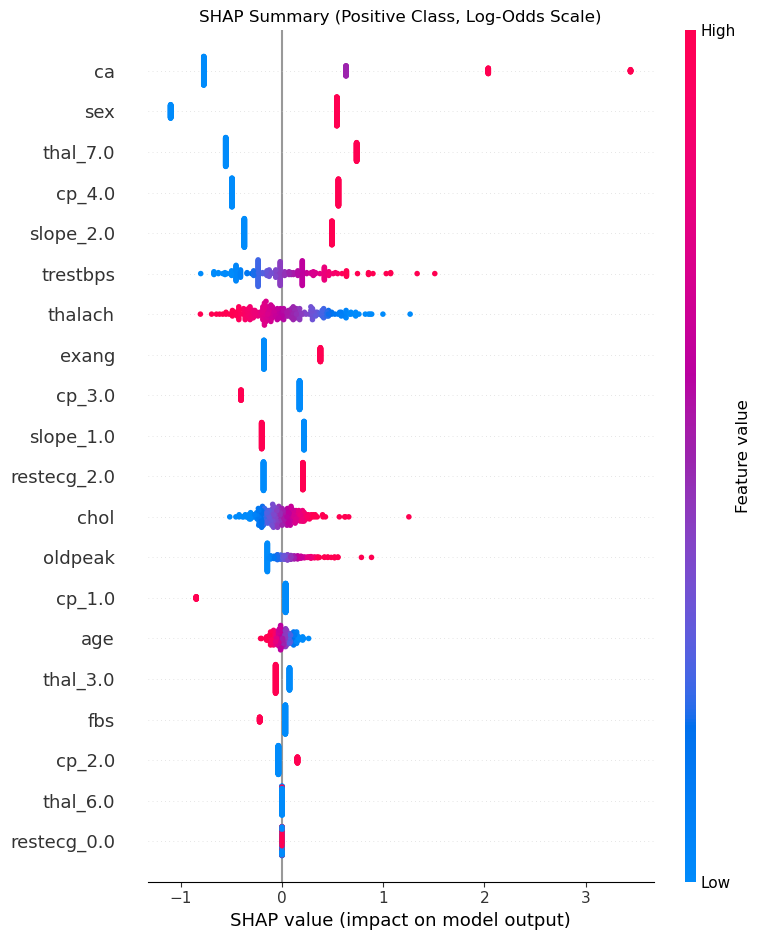

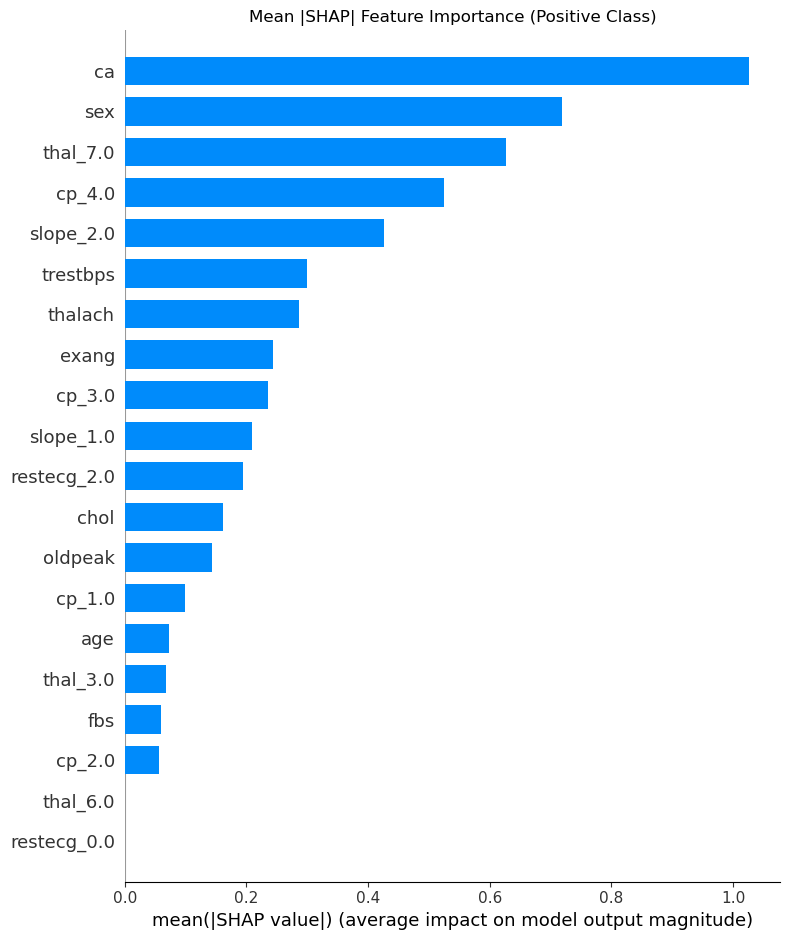

Saved SHAP summary plot: figures/shap/shap_summary_beeswarm.png
Saved SHAP bar plot: figures/shap/shap_bar_mean_abs.png
Saved SHAP feature table: figures/shap/top_features_mean_abs_shap.csv
Interpretation note: values explain contribution to positive class (num=1) on log-odds scale.
Real transformed feature names were derived from fitted preprocessor internals.


In [30]:
try:
    import shap
except ImportError as exc:
    raise ImportError(
        "Step 5.3 requires the 'shap' package. Install it with: pip install shap"
    ) from exc

import matplotlib.pyplot as plt
import numpy as np

fitted_preprocessor = reloaded_pipeline.named_steps["preprocessor"]
fitted_model = reloaded_pipeline.named_steps["model"]

X_transformed = fitted_preprocessor.transform(X)

def get_real_transformed_feature_names(preprocessor, X_ref, X_transformed_ref):
    """Return transformed feature names from fitted ColumnTransformer internals."""
    try:
        names = preprocessor.get_feature_names_out()
        names = [str(n) for n in names]
        if len(names) == X_transformed_ref.shape[1]:
            return names
    except Exception:
        pass

    if not hasattr(preprocessor, "transformers_"):
        raise RuntimeError("Preprocessor is not fitted or has no transformers_.")

    out_names = []
    for t_name, trans, cols in preprocessor.transformers_:
        if t_name == "remainder" and trans == "drop":
            continue
        if trans == "drop":
            continue

        if isinstance(cols, slice):
            cols_list = list(X_ref.columns[cols])
        elif hasattr(cols, "tolist"):
            cols_list = list(cols.tolist())
        elif isinstance(cols, (list, tuple)):
            cols_list = list(cols)
        else:
            cols_list = [cols]

        cols_list = [str(c) for c in cols_list]

        if trans == "passthrough":
            out_names.extend(cols_list)
            continue

        if hasattr(trans, "named_steps"):
            last_step = trans.steps[-1][1]

            if hasattr(last_step, "categories_"):
                for col_name, cats in zip(cols_list, last_step.categories_):
                    for cat in cats:
                        out_names.append(f"{col_name}_{cat}")
                continue

            out_names.extend(cols_list)
            continue

        if hasattr(trans, "get_feature_names_out"):
            try:
                trans_names = trans.get_feature_names_out(cols_list)
                out_names.extend([str(n) for n in trans_names])
                continue
            except Exception:
                try:
                    trans_names = trans.get_feature_names_out()
                    out_names.extend([str(n) for n in trans_names])
                    continue
                except Exception:
                    pass

        out_names.extend(cols_list)

    if len(out_names) != X_transformed_ref.shape[1]:
        raise RuntimeError(
            "Could not reliably reconstruct transformed feature names. "
            f"Got {len(out_names)} names for {X_transformed_ref.shape[1]} columns."
        )

    return out_names

transformed_feature_names = get_real_transformed_feature_names(
    fitted_preprocessor,
    X,
    X_transformed,
)

explainer = shap.LinearExplainer(fitted_model, X_transformed)
shap_values = explainer(X_transformed)

values = shap_values.values
if values.ndim == 3:
    values = values[:, :, 1]
elif values.ndim != 2:
    raise ValueError(f"Unexpected SHAP values shape: {values.shape}")

plt.figure(figsize=(10, 6))
shap.summary_plot(values, X_transformed, feature_names=transformed_feature_names, show=False)
plt.title("SHAP Summary (Positive Class, Log-Odds Scale)")
plt.tight_layout()
plt.show()
plt.savefig(shap_dir / "shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 6))
shap.summary_plot(values, X_transformed, feature_names=transformed_feature_names, plot_type="bar", show=False)
plt.title("Mean |SHAP| Feature Importance (Positive Class)")
plt.tight_layout()
plt.show()
plt.savefig(shap_dir / "shap_bar_mean_abs.png", dpi=300, bbox_inches="tight")
plt.close()

mean_abs_shap = np.abs(values).mean(axis=0)
top_features = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

top_features.to_csv(shap_dir / "top_features_mean_abs_shap.csv", index=False)

print(f"Saved SHAP summary plot: {Path('figures/shap/shap_summary_beeswarm.png')}")
print(f"Saved SHAP bar plot: {Path('figures/shap/shap_bar_mean_abs.png')}")
print(f"Saved SHAP feature table: {Path('figures/shap/top_features_mean_abs_shap.csv')}")
print("Interpretation note: values explain contribution to positive class (num=1) on log-odds scale.")
print("Real transformed feature names were derived from fitted preprocessor internals.")



The SHAP results match across the CSV and both plots.

Top features are:

- `ca` (~1.03)
- `sex` (~0.72)
- `thal_7.0` (~0.63)
- `cp_4.0` (~0.52)
- `slope_2.0` (~0.43)

Among continuous features, `trestbps` and `thalach` matter most.

In the beeswarm plot, higher `ca`, `sex=1`, and having `thal_7.0`, `cp_4.0`, or `slope_2.0` usually increase predicted heart-disease risk.
thalach is mostly the opposite: higher values tend to lower predicted risk.

Some encoded categories (like `thal_6.0` and `restecg_0.0`) have almost no effect in the final LR Elastic Net model.